In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from scipy.stats import randint
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

import joblib

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [3]:
print(X_train.shape, X_test.shape)
print(type(y_train), type(y_test))

(735, 23) (184, 23)
<class 'pandas.Series'> <class 'pandas.Series'>


In [7]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [4]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Naive Bayes':         GaussianNB()
}

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipeline,
        X_train, y_train,
        cv=cv,
        scoring=['f1', 'roc_auc', 'precision', 'recall'],
        return_train_score=False
    )
    
    results[name] = {
        'F1':        scores['test_f1'].mean().round(3),
        'ROC-AUC':   scores['test_roc_auc'].mean().round(3),
        'Precision': scores['test_precision'].mean().round(3),
        'Recall':    scores['test_recall'].mean().round(3)
    }

results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
print(results_df)

                        F1  ROC-AUC  Precision  Recall
Logistic Regression  0.829    0.883      0.820   0.840
Gradient Boosting    0.819    0.863      0.819   0.820
SVM                  0.816    0.871      0.795   0.840
Random Forest        0.810    0.856      0.808   0.813
Naive Bayes          0.788    0.858      0.838   0.744
KNN                  0.782    0.822      0.765   0.801
Decision Tree        0.726    0.704      0.745   0.710


In [ ]:
from scipy.stats import uniform

lr_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

param_dist_lr = {
    'model__C':      uniform(0.01, 10),
    'model__solver': ['liblinear', 'saga']
}

random_search_lr = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_dist_lr,
    n_iter=20,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search_lr.fit(X_train, y_train)

print("Best Params:", random_search_lr.best_params_)
print("Best F1:", round(random_search_lr.best_score_, 3))

Best Params: {'model__C': np.float64(0.5908361216819946), 'model__solver': 'saga'}
Best F1: 0.83


In [18]:
gbc_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,random_state=None,max_features=None))
])
param_dist_gbc = {
    'model__n_estimators':  randint(50, 300),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth':     randint(2, 8),
    'model__subsample':     uniform(0.6, 0.4)
}
random_search_gbc = RandomizedSearchCV(
    estimator=gbc_pipeline,
    param_distributions=param_dist_gbc,
    n_iter=20,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)



random_search_gbc.fit(X_train, y_train)
print("Best Params:", random_search_gbc.best_params_)
print("Best F1:", round(random_search_gbc.best_score_, 3))

Best Params: {'model__learning_rate': np.float64(0.01691872751242473), 'model__max_depth': 4, 'model__n_estimators': 108, 'model__subsample': np.float64(0.7599443886861021)}
Best F1: 0.826


In [19]:
SVM_pipeline = Pipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  SVC(probability=True, random_state=42))
])
param_dist_SVM = {
    'model__C':      uniform(0.01, 10),
    'model__kernel' : ["rbf", "linear", "poly"],
    'model__gamma' : ['scale', 'auto']
}
random_search_SVM = RandomizedSearchCV(
    estimator=SVM_pipeline,
    param_distributions=param_dist_SVM,
    n_iter=20,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)



random_search_SVM.fit(X_train, y_train)
print("Best Params:", random_search_SVM.best_params_)
print("Best F1:", round(random_search_SVM.best_score_, 3))

Best Params: {'model__C': np.float64(0.21584494295802448), 'model__gamma': 'auto', 'model__kernel': 'linear'}
Best F1: 0.826


              precision    recall  f1-score   support

           0       0.85      0.76      0.80        82
           1       0.82      0.89      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.83       184
weighted avg       0.83      0.83      0.83       184

ROC-AUC: 0.913


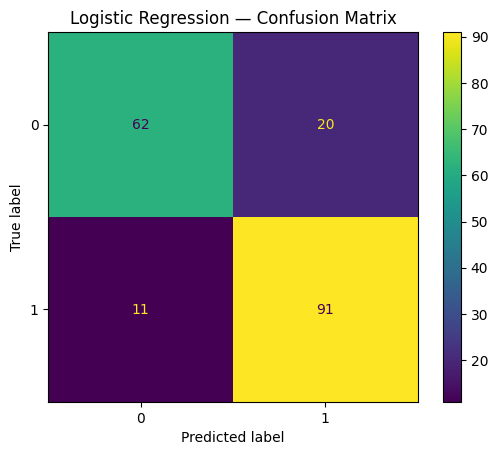

In [20]:
lr_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000,solver='saga',C=0.59))
])

model=lr_pipeline.fit(X_train,y_train)
model.predict(X_test)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [21]:
import joblib
joblib.dump(model, '../models/lr_best_model.pkl')
print("Model saved.")

Model saved.
